<h1 style="color:darkblue;text-align:center;">Disaster Tweet Classification using NLP</h1>

<p style="text-align:center;">
This project uses <span style="color:green">Machine Learning</span> and 
<span style="color:orange">Natural Language Processing</span> to classify tweets as 
<span style="color:red">Disaster</span> or 
<span style="color:blue">Non-Disaster</span>.
</p>

<h2 style="color:purple;">1️⃣ Import Required Libraries</h2>

In this step we import all the necessary libraries required for data analysis, visualization and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

<h2 style="color:purple;">2️⃣ Load Dataset</h2>

The dataset contains tweets collected from Twitter.

Each tweet is labeled as:
<span style="color:red">Disaster Tweet (1)</span> or 
<span style="color:blue">Non-Disaster Tweet (0)</span>.

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\twitter_disaster (1).csv")

df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


<h2 style="color:purple;">3️⃣ Dataset Understanding</h2>

Explore the dataset structure including:

• Number of rows and columns  
• Data types  
• Statistical summary

<h3 style="color:green;">Dataset Shape</h3>

This step shows the number of rows and columns present in the dataset.

In [3]:
df.shape

(7613, 5)

<h3 style="color:orange;">Dataset Information</h3>

This step provides details about the dataset including column names, data types, and non-null values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


<h3 style="color:blue;">Statistical Description</h3>

This step shows the statistical summary of numerical columns such as mean, standard deviation, minimum and maximum values.

In [5]:
df.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


<h2 style="color:purple;">4️⃣ Missing Values Analysis</h2>

Here check if there are any missing values in the dataset and identify the columns where data is missing.

In [6]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

<h2 style="color:purple;">5️⃣ Select Required Columns</h2>

Remove unnecessary columns and keep only the columns required for the NLP model.

<span style="color:blue;">text</span> : Contains tweet content  

<span style="color:orange;">target</span> : Indicates whether the tweet is related to a disaster or not.

In [7]:
df = df[['text','target']]
df.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


<h3 style="color:green;">📊 Target Distribution Graph</h3>

This visualization shows the distribution of disaster and non-disaster tweets in the dataset.

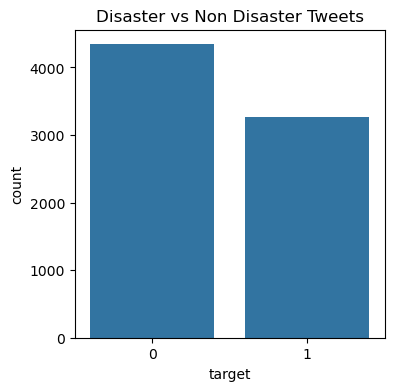

In [8]:
plt.figure(figsize=(4,4))
sns.countplot(x='target', data=df)
plt.title('Disaster vs Non Disaster Tweets')
plt.show()

The graph shows the number of tweets labeled as:

<span style="color:red;">1 → Disaster Tweet</span>  
<span style="color:blue;">0 → Non Disaster Tweet</span>

<h3 style="color:green;">📏 Tweet Length Analysis</h3>

This analysis shows the distribution of tweet lengths in the dataset.
It helps us understand how long tweets usually are.

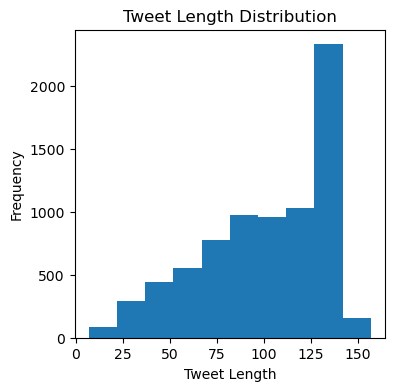

In [9]:
plt.figure(figsize=(4,4))
df['length'] = df['text'].apply(len)

plt.hist(df['length'])

plt.title("Tweet Length Distribution")

plt.xlabel("Tweet Length")

plt.ylabel("Frequency")

plt.show()

The histogram shows how tweet lengths are distributed in the dataset. 
Most tweets fall within a certain length range.

<h3 style="color:green;">🔤 Most Common Words in Tweets</h3>

This analysis identifies the most frequently occurring words in the dataset.
It helps us understand which words appear most often in tweets.

In [10]:
from collections import Counter

words = " ".join(df['text']).split()

common_words = Counter(words).most_common(10)


for word, count in common_words:
    print(word, ":", count)


the : 2575
a : 1845
to : 1805
in : 1757
of : 1722
and : 1302
I : 1197
for : 820
is : 814
on : 773


This step shows the top 10 most frequent words used in the tweets dataset.
These words help identify common patterns in the text data.

<h3 style="color:green;"> WordCloud Visualization</h3>

WordCloud visualization highlights the most frequently used words in tweets.

<h3 style="color:green;">☁️ WordCloud for Non-Disaster Tweets</h3>

This visualization highlights the most frequently used words in tweets that are not related to disasters.

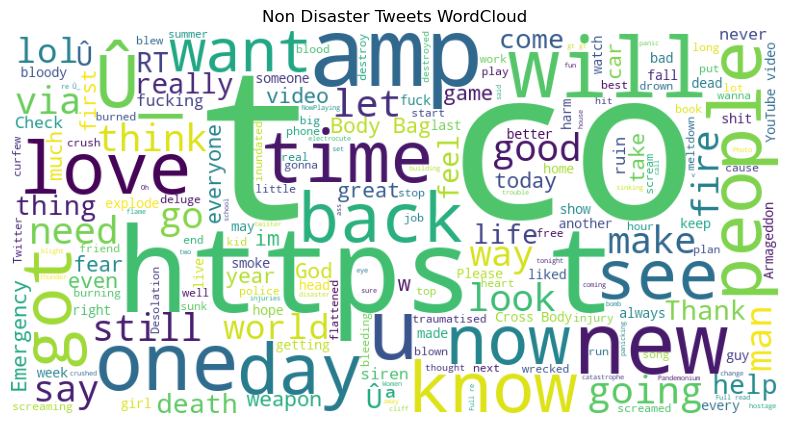

In [11]:
normal_tweets = df[df['target'] == 0]['text']

text = " ".join(normal_tweets)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Non Disaster Tweets WordCloud")

plt.show()

The WordCloud shows the most common words used in non-disaster tweets. 
Larger words in the cloud indicate higher frequency.

<h3 style="color:green;">🔥 WordCloud for Disaster Tweets</h3>

This visualization highlights the most frequently used words in tweets related to disasters.

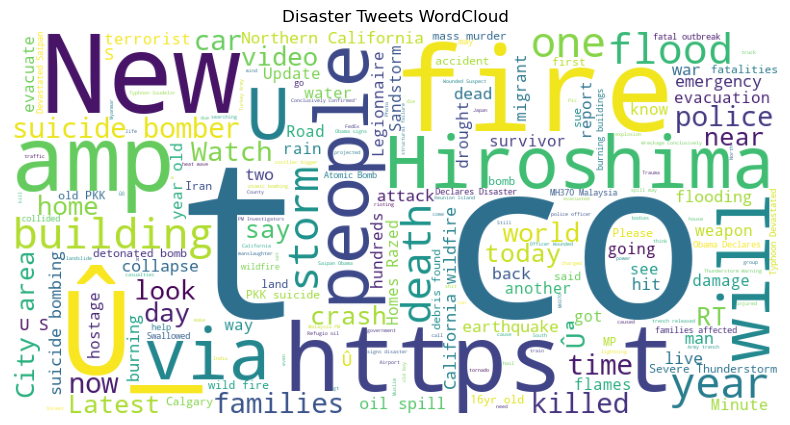

In [12]:
disaster_tweets = df[df['target'] == 1]['text']

text = " ".join(disaster_tweets)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Disaster Tweets WordCloud")

plt.show()

The WordCloud shows the most common words used in non-disaster tweets. 
Larger words in the cloud indicate higher frequency.

<h2 style="color:purple;">6️⃣ Text Cleaning</h2>

Tweets often contain URLs, hashtags, numbers and special characters.

In this step we clean the text to improve the performance of the machine learning model.

In [13]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    return text

df['clean_text'] = df['text'].apply(clean_text)

df.head()

,text,target,length,clean_text
0,Our Deeds are the Reason of this #earthquake M...,1,69,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,1,38,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,1,133,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",1,65,people receive wildfires evacuation orders in...
4,Just got sent this photo from Ruby #Alaska as ...,1,88,just got sent this photo from ruby alaska as s...


<h2 style="color:purple;">7️⃣ Feature Engineering (TF-IDF)</h2>

TF-IDF converts textual data into numerical features so that machine learning models can understand the text.

In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['target']

<h2 style="color:purple;">8️⃣ Train Test Split</h2>

The dataset is divided into:

<span style="color:green">Training Data (80%)</span>  
<span style="color:orange">Testing Data (20%)</span>

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h2 style="color:purple;">9️⃣ Model Training</h2>

 Train a 
<span style="color:orange">Logistic Regression</span> model to classify tweets into disaster and non-disaster categories.

In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Prediction

In [17]:
pred = model.predict(X_test)

<h2 style="color:purple;">🔟 Model Evaluation</h2>

The model performance is evaluated using:

• Accuracy  
• Precision  
• Recall  
• F1 Score

In [18]:
print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.8063033486539725
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       874
           1       0.83      0.69      0.75       649

    accuracy                           0.81      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.81      0.81      0.80      1523



<h2 style="color:purple;">1️⃣1️⃣ Confusion Matrix</h2>

Confusion Matrix helps visualize the performance of the classification model by comparing predicted values with actual values.

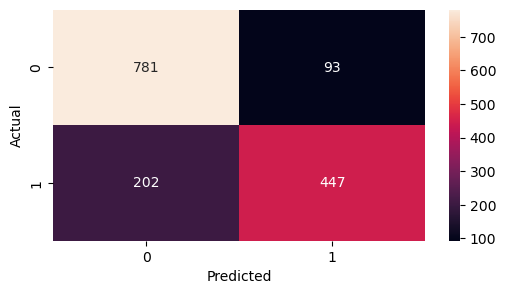

In [19]:
plt.figure(figsize=(6,3))
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<h2 style="color:purple;">1️⃣2️⃣ Model Serialization</h2>

The trained model is saved using <span style="color:green">pickle</span> so that it can be reused later without retraining.

In [20]:
pickle.dump(model, open("disaster_model.pkl","wb"))

pickle.dump(tfidf, open("vectorizer.pkl","wb"))

<h2 style="color:purple;">1️⃣3️⃣ Final Tweet Prediction</h2>

In this step we test the trained model by entering a new tweet and predicting whether it is a 
<span style="color:red">Disaster Tweet</span> 
or 
<span style="color:blue">Non-Disaster Tweet</span>.

In [21]:
tweet = ['Huge fire in the city']

vec = tfidf.transform(tweet)

prediction = model.predict(vec)

if prediction[0] == 1:
    print("Disaster Tweet")
else:
    print("Not a Disaster Tweet")

Disaster Tweet


<h2 style="color:darkgreen;">1️⃣4️⃣ Conclusion</h2>

In this project we successfully developed a machine learning model that can classify tweets as disaster or non-disaster.

The model was trained using <span style="color:orange">TF-IDF</span> features and 
<span style="color:purple">Logistic Regression</span> algorithm.
